In [ ]:
from src.paths import ROOT
from src.utils import *
from src.rsa.brain_rsa import BrainRSA, BrainRSAPlotsManager
from src.indexing_and_formatting.image_indexing_utils import shared_subset
import numpy as np
import os
from scipy.stats import spearmanr


## Computing Noise Ceilings

In [6]:
def compute_noise_ceilings(roi: str):
    n_images = 906
    dim_rdm = (n_images * n_images - n_images) / 2
    rdms = np.empty((8, int(dim_rdm)))
    for participant in range(1,9):
        part_rdms = open_pickle(ROOT / f'results/cached_brain_rdms/part-{participant}.pkl')
        rdms[participant-1] = part_rdms[roi]

    mean_rdm = rdms.mean(axis=0)
    ub_arr, lb_arr = np.empty(8), np.empty(8)
    for i in range(8):
        ub_arr[i], _ = spearmanr(rdms[i], mean_rdm)
        mean_wo_part = rdms[[el for el in np.arange(8) if el != i]].mean(axis=0)
        lb_arr[i], _ = spearmanr(rdms[i], mean_wo_part)

    return ub_arr.mean().item(), lb_arr.mean().item()
        
nc = {}
for roi in ['all', 'faces', 'places', 'bodies']:
    ub, lb = compute_noise_ceilings(roi)
    nc[roi] = {'ub': ub, 'lb':lb}


In [7]:
nc

{'all': {'ub': 0.6211379024058427, 'lb': 0.4796834888519249},
 'faces': {'ub': 0.5997509536439958, 'lb': 0.45076447193719427},
 'places': {'ub': 0.6505657288889479, 'lb': 0.5275663492192064},
 'bodies': {'ub': 0.6296933125621783, 'lb': 0.4924945899697415}}

## Analysing Results

In [2]:
noise_ceilings = {'all': {'ub': 0.6211379024058427, 'lb': 0.4796834888519249},
 'faces': {'ub': 0.5997509536439958, 'lb': 0.45076447193719427},
 'places': {'ub': 0.6505657288889479, 'lb': 0.5275663492192064},
 'bodies': {'ub': 0.6296933125621783, 'lb': 0.4924945899697415}}

In [3]:
pm = BrainRSAPlotsManager(results_path=ROOT / 'results/brain_rsa/{model_id}.pkl', noise_ceilings=noise_ceilings)

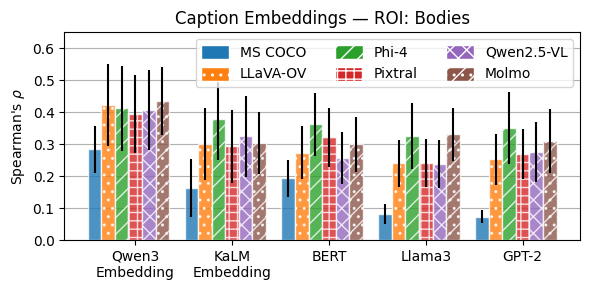

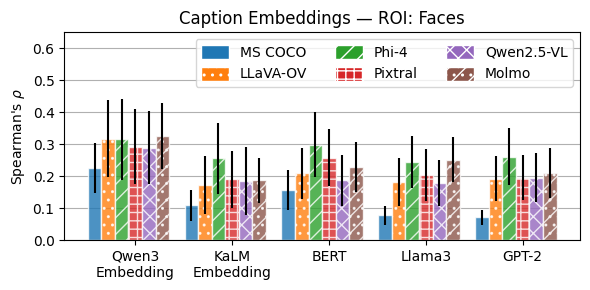

In [4]:
for roi in ['bodies', 'faces']:
    pm.barplot_all_encoders(target_roi=roi, normalise=True, save=True, file_name=f'brain_rsa_{roi}')

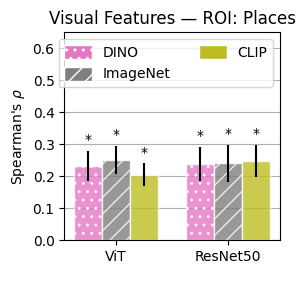

In [4]:
roi = 'places'
pm.barplot_visual_best_layer(target_roi=roi,  normalise=True, save=True, file_name=f'brain_rsa_vf_{roi}')


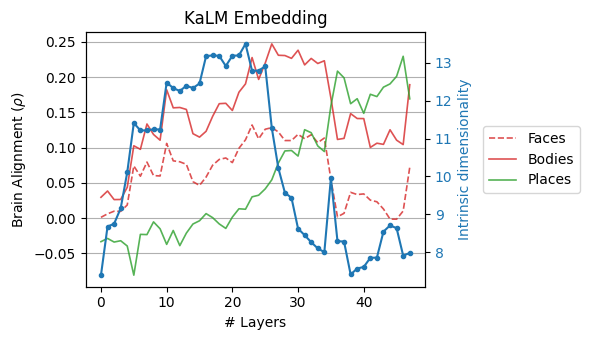

In [10]:
pm = BrainRSAPlotsManager(results_path=ROOT / 'results/brain_rsa/{model_id}.pkl', noise_ceilings=noise_ceilings)
embedder = 'kalm'
pm.linechart_intrinsic_dimensionality_all_rois(embedder, save=True, file_name = f"brain_rsa_id_{embedder}_all_rois")

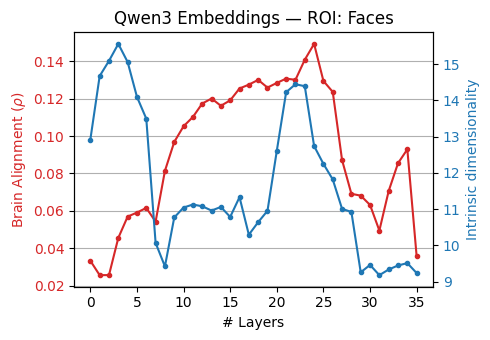

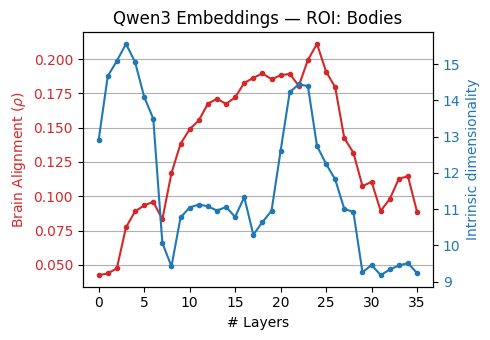

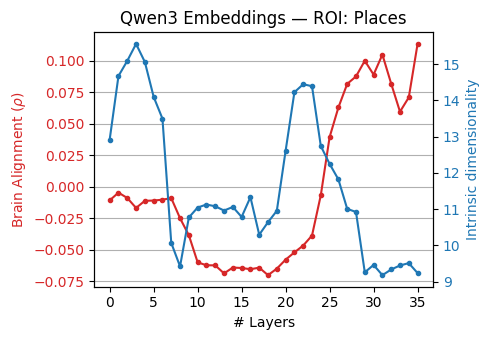

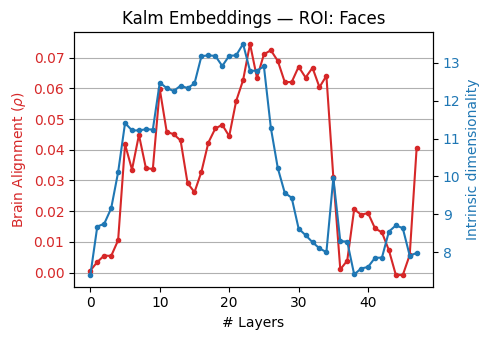

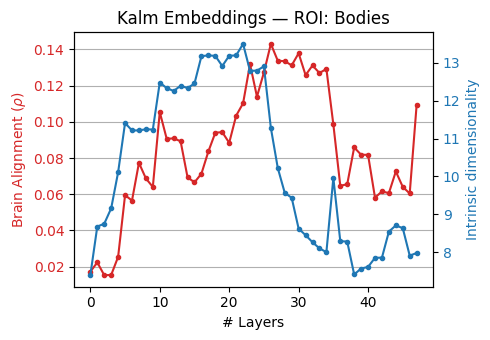

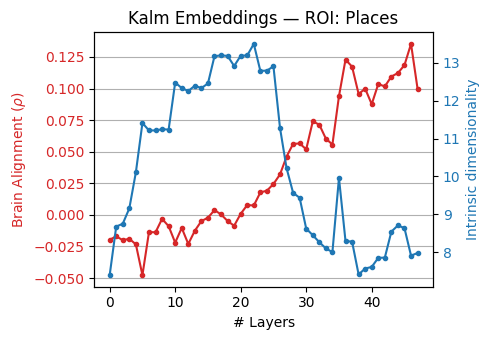

In [4]:
pm = BrainRSAPlotsManager(results_path=ROOT / 'results/brain_rsa/{model_id}.pkl', noise_ceilings=noise_ceilings)
for embedder in ['qwen3', 'kalm']:
    for roi in ['faces', 'bodies', 'places']:
        pm.linechart_intrinsic_dimensionality(embedder, roi)